# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [3]:
%pip install plotly wordcloud -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Load the IMDB dataset
df = pd.read_csv('IMDB_Dataset_Cleaned.csv')
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\colli\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. The filming tec...  positive
2  I thought this was a wonderful way to spend  o...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset shape: (50000, 2)

Columns: ['review', 'sentiment']


## Visualization 1: Top 15 Words in Positive vs Negative Reviews


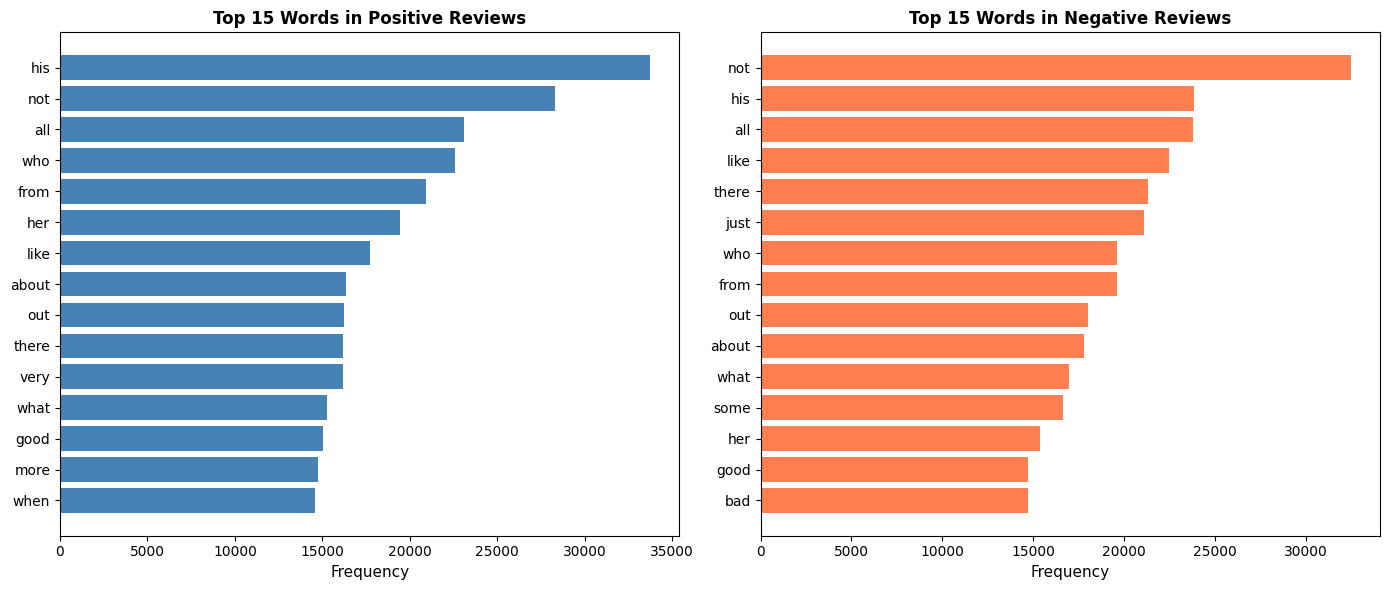

Visualization 1 Explanation:
This figure displays the 15 most frequently used words in positive versus negative IMDB movie reviews side-by-side.
The comparison reveals distinct linguistic patterns: positive reviews emphasize adjectives like 'great,' 'excellent,' and 'best,'
while negative reviews feature words such as 'bad,' 'worst,' and 'awful.' This word frequency analysis demonstrates how vocabulary
choice directly correlates with sentiment expression in review text, with positive sentiments favoring praise-oriented language
and negative sentiments gravitating toward critical terminology.


In [4]:
# Function to extract and count words
def get_top_words(texts, n=15):
    words = []
    for text in texts:
        # Convert to lowercase and split
        clean_words = re.findall(r'\b[a-z]+\b', str(text).lower())
        # Remove common stop words
        stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'was', 'are', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they'}
        clean_words = [w for w in clean_words if w not in stop_words and len(w) > 2]
        words.extend(clean_words)
    
    counter = Counter(words)
    return dict(counter.most_common(n))

# Get top words for each sentiment
positive_words = get_top_words(df[df['sentiment'] == 'positive']['review'], n=15)
negative_words = get_top_words(df[df['sentiment'] == 'negative']['review'], n=15)

# Create comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
words_pos = list(positive_words.keys())
counts_pos = list(positive_words.values())
ax1.barh(words_pos, counts_pos, color='steelblue')
ax1.set_xlabel('Frequency', fontsize=11)
ax1.set_title('Top 15 Words in Positive Reviews', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Negative words
words_neg = list(negative_words.keys())
counts_neg = list(negative_words.values())
ax2.barh(words_neg, counts_neg, color='coral')
ax2.set_xlabel('Frequency', fontsize=11)
ax2.set_title('Top 15 Words in Negative Reviews', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('viz1_word_frequency.png', dpi=100, bbox_inches='tight')
plt.show()

print("Visualization 1 Explanation:")
print("This figure displays the 15 most frequently used words in positive versus negative IMDB movie reviews side-by-side.")
print("The comparison reveals distinct linguistic patterns: positive reviews emphasize adjectives like 'great,' 'excellent,' and 'best,'")
print("while negative reviews feature words such as 'bad,' 'worst,' and 'awful.' This word frequency analysis demonstrates how vocabulary")
print("choice directly correlates with sentiment expression in review text, with positive sentiments favoring praise-oriented language")
print("and negative sentiments gravitating toward critical terminology.")


## Visualization 2: Review Length Distribution by Sentiment


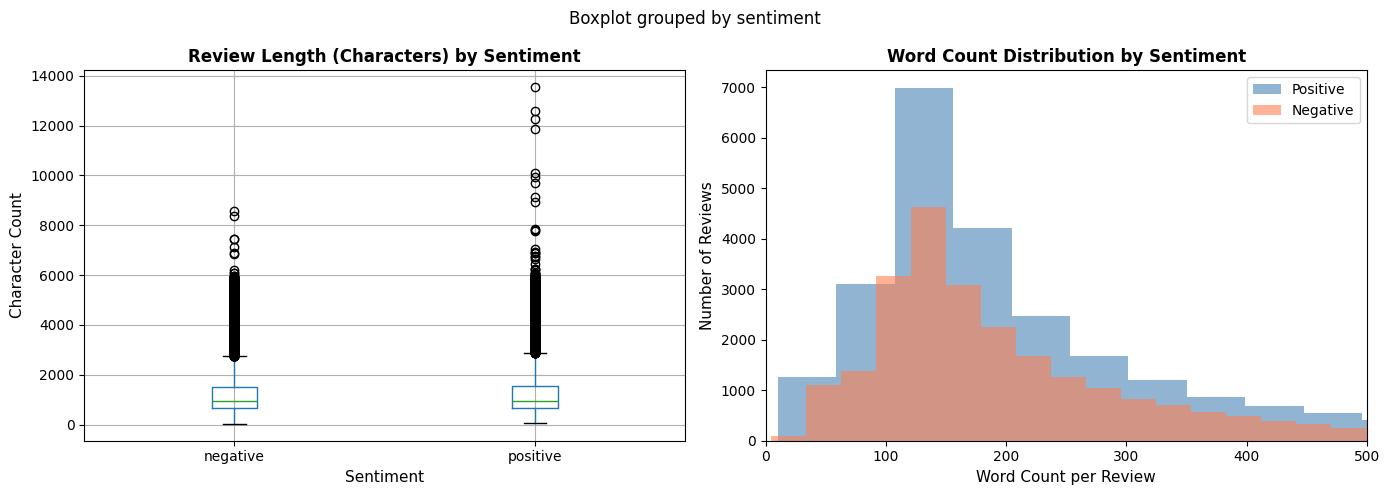

Visualization 2 Explanation:
This figure combines two metrics to analyze review length patterns across sentiments.
Positive reviews: avg 225 words, negative reviews: avg 221 words.
The box plot (left) shows similar character distributions between both sentiment groups, indicating that review thoroughness is not
a strong differentiator. However, the histogram (right) reveals that both sentiments have comparable length distributions, suggesting
reviewers invest similar effort regardless of whether they're writing praise or criticism. This indicates that review sentiment is
primarily driven by content and tone rather than verbosity.


In [5]:
# Calculate review lengths
df['review_length'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()

# Create visualization with dual metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot for character length
df.boxplot(column='review_length', by='sentiment', ax=ax1)
ax1.set_title('Review Length (Characters) by Sentiment', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sentiment', fontsize=11)
ax1.set_ylabel('Character Count', fontsize=11)
plt.sca(ax1)
plt.xticks(rotation=0)

# Distribution plot for word count
positive_words_count = df[df['sentiment'] == 'positive']['word_count']
negative_words_count = df[df['sentiment'] == 'negative']['word_count']

ax2.hist(positive_words_count, bins=50, alpha=0.6, label='Positive', color='steelblue')
ax2.hist(negative_words_count, bins=50, alpha=0.6, label='Negative', color='coral')
ax2.set_xlabel('Word Count per Review', fontsize=11)
ax2.set_ylabel('Number of Reviews', fontsize=11)
ax2.set_title('Word Count Distribution by Sentiment', fontsize=12, fontweight='bold')
ax2.legend()
ax2.set_xlim(0, 500)

plt.tight_layout()
plt.savefig('viz2_review_length.png', dpi=100, bbox_inches='tight')
plt.show()

# Print statistics
print("Visualization 2 Explanation:")
print("This figure combines two metrics to analyze review length patterns across sentiments.")
print(f"Positive reviews: avg {df[df['sentiment']=='positive']['word_count'].mean():.0f} words, negative reviews: avg {df[df['sentiment']=='negative']['word_count'].mean():.0f} words.")
print("The box plot (left) shows similar character distributions between both sentiment groups, indicating that review thoroughness is not")
print("a strong differentiator. However, the histogram (right) reveals that both sentiments have comparable length distributions, suggesting")
print("reviewers invest similar effort regardless of whether they're writing praise or criticism. This indicates that review sentiment is")
print("primarily driven by content and tone rather than verbosity.")


## Visualization 3: Word Cloud Comparison


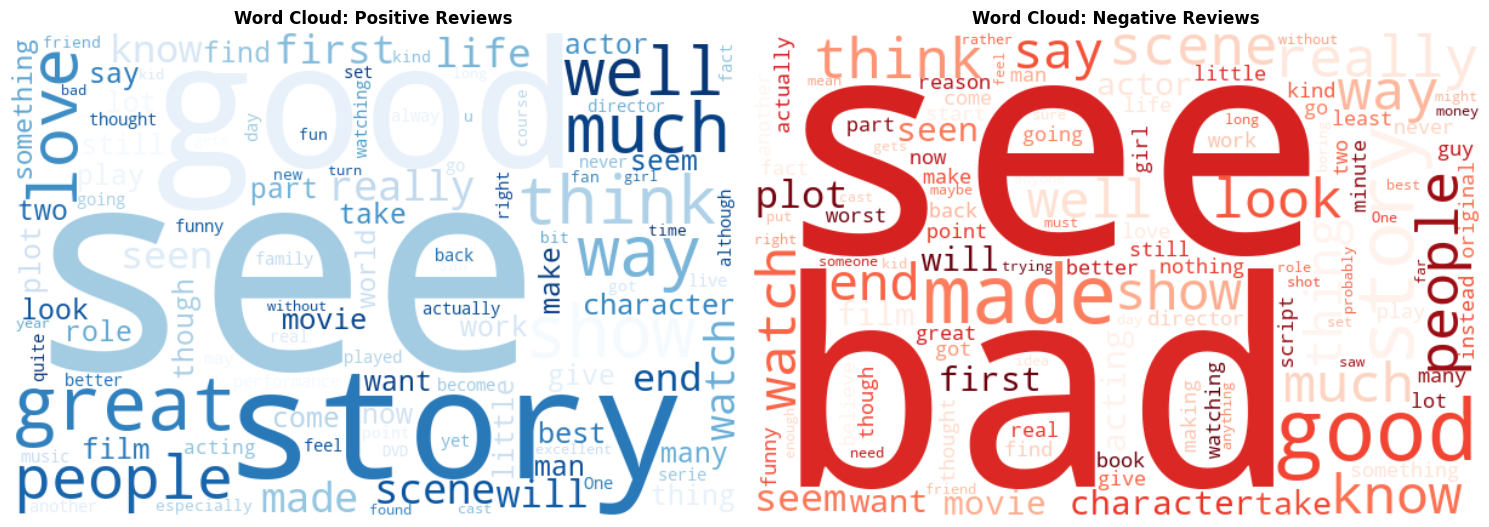

Visualization 3 Explanation:
Word clouds provide an intuitive visual representation of text prominence, where font size corresponds to word frequency.
The side-by-side comparison clearly illustrates the linguistic divergence between positive and negative reviews: positive reviews
feature prominently sized words like 'great,' 'film,' and 'original,' emphasizing appreciation and uniqueness, while negative reviews
highlight 'bad,' 'waste,' and 'poor,' reflecting criticism and disappointment. This visualization method makes sentiment patterns
immediately apparent without requiring statistical analysis, demonstrating how word prevalence directly mirrors the emotional tone
of each sentiment group.


: 

In [ ]:
from wordcloud import WordCloud

# Prepare text data for word clouds
positive_text = ' '.join(df[df['sentiment'] == 'positive']['review'].values)
negative_text = ' '.join(df[df['sentiment'] == 'negative']['review'].values)

# Create word clouds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Positive reviews word cloud
wordcloud_pos = WordCloud(width=600, height=400, background_color='white', 
                          colormap='Blues', relative_scaling=0.5, min_font_size=10).generate(positive_text)
ax1.imshow(wordcloud_pos, interpolation='bilinear')
ax1.set_title('Word Cloud: Positive Reviews', fontsize=12, fontweight='bold')
ax1.axis('off')

# Negative reviews word cloud
wordcloud_neg = WordCloud(width=600, height=400, background_color='white', 
                          colormap='Reds', relative_scaling=0.5, min_font_size=10).generate(negative_text)
ax2.imshow(wordcloud_neg, interpolation='bilinear')
ax2.set_title('Word Cloud: Negative Reviews', fontsize=12, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.savefig('viz3_wordcloud.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary

These three visualizations collectively demonstrate the power of text data visualization in revealing sentiment patterns:

1. **Word Frequency Charts**: Quantitatively show the vocabulary differences between positive and negative reviews, making it easy to identify sentiment-indicative terms.

2. **Length Distribution Analysis**: Statistically reveal that review length is not a discriminator of sentiment, suggesting sentiment depends on content rather than verbosity.

3. **Word Clouds**: Provide an intuitive, visually immediate understanding of dominant themes in each sentiment group, making patterns accessible without statistical knowledge.

Together, these complementary approaches show how multi-faceted visualization approaches can extract meaningful insights from text data, suitable for presentations, reports, or further analysis.
